# **CODE REUSE SESSION 2 - PYTHON NOTEBOOK 2 : Classification Modelling & Hyperparameter Tuning**


**Author :** Lafira Casseer | 20232643 | w2149495

**Module :** 5DATA002W.2 – Machine Learning & Data Mining

**Conducted by :** Mr.Fouzul Hassan  **ON**  13/03/2026


---



---












# **SET-UP ENVIRONMENT**



---




## Code Reuse Session 2 - Prompt 1

In [ ]:
#Importing pandas library
import pandas as pd

## Code Reuse Session 2 - Prompt 2

In [ ]:
#Loading the prepared classification dataset
data = pd.read_csv('/content/drive/MyDrive/loan_classification_prepared.csv')

## Code Reuse Session 2 - Prompt 3

In [ ]:
#Displaying the first 15 records
data.head(15)

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,-1.085959,-1.372113,2,-1.174384,1,1.039323,-1.337932,-0.427871,0,-0.450173,0
1,-1.085959,-1.340478,2,-0.675015,1,2.836623,1.934176,0.335601,1,-0.698359,0
2,-0.754442,-1.435385,3,0.074038,3,3.735273,0.625333,1.644410,0,-0.698359,0
3,2.063458,3.109710,3,-0.425331,1,4.633923,-0.683511,0.335601,0,1.287123,0
4,2.063458,0.684204,0,-0.425331,2,4.633923,0.625333,2.516950,0,2.031679,0
5,2.063458,1.765195,0,1.072775,5,3.735273,-1.010721,0.771871,0,1.783493,0
6,2.063458,2.265987,0,1.072775,0,2.836623,0.298122,0.117466,0,1.287123,0
7,2.063458,1.791452,0,-0.425331,2,2.836623,1.934176,0.662804,0,2.776234,0
8,2.063458,0.420574,0,-0.675015,0,2.836623,-0.029089,1.644410,0,1.287123,0
9,2.063458,0.420574,0,1.072775,5,2.836623,2.588597,1.535343,0,2.776234,0


## Code Reuse Session 2 - Prompt 4

In [ ]:
#Exploring data types for all variables to ensure compatibility for modelling
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58639 entries, 0 to 58638
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58639 non-null  float64
 1   income                   58639 non-null  float64
 2   home_ownership           58639 non-null  int64  
 3   employment_length        58639 non-null  float64
 4   loan_intent              58639 non-null  int64  
 5   loan_amount              58639 non-null  float64
 6   loan_interest_rate       58639 non-null  float64
 7   loan_income_ratio        58639 non-null  float64
 8   payment_default_on_file  58639 non-null  int64  
 9   credit_history_length    58639 non-null  float64
 10  loan_approval_status     58639 non-null  int64  
dtypes: float64(7), int64(4)
memory usage: 4.9 MB


## Code Reuse Session 2 - Prompt 5

In [ ]:
#Controlling the number of rows and columns truncated when displaying the dataframe

#Setting max displayed rows to 500 to prevent row truncation
pd.set_option('display.max_rows', 500)

#Setting max displayed columns to 500 to prevent column truncation
pd.set_option('display.max_columns', 500)

#Setting the display width to 150 for better readability
pd.set_option('display.width', 150)

## Code Reuse Session 2 - Prompt 6

In [ ]:
#Declaring the input features (X) and output target variable(y) for the classification modelling

#Declaring the list of input feature names for the classification model
feature_cols = ['age', 'income', 'home_ownership', 'employment_length', 'loan_intent',
                'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
                'payment_default_on_file', 'credit_history_length']

#assigning input features to X
X = data[feature_cols]  # Features

#assigning the target output variable to y
y = data['loan_approval_status']

#Confirming feature names and dataset shape
print('Feature names used:', feature_cols)
print('X shape:', X.shape)
print('y shape:', y.shape)

Feature names used: ['age', 'income', 'home_ownership', 'employment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
X shape: (58639, 10)
y shape: (58639,)


## Code Reuse Session 2 - Prompt 7

In [ ]:
#Importing train_test_split from sklearn to randomly sample training and test subsets
from sklearn.model_selection import train_test_split

## Code Reuse Session 2 - Prompt 8

In [ ]:
#Splitting dataset into training and test subsets at 80/20 ratio
#random_state=42 ensures reproducible sampling
#stratify=y ensures the Approved/Rejected label ratio is preserved in both subsets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Confirming shape and class distribution of each subset
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Training class distribution:', y_train.value_counts().to_dict())
print('Test class distribution:', y_test.value_counts().to_dict())

X_train shape: (46911, 10)
X_test shape: (11728, 10)
Training class distribution: {0: 40232, 1: 6679}
Test class distribution: {0: 10058, 1: 1670}




---



# **MODEL 1 - LOGISTIC REGRESSION (LR)**

---






## Code Reuse Session 2 - Prompt 9

In [ ]:
#Importing LogisticRegression from the sklearn module
from sklearn.linear_model import LogisticRegression

## Code Reuse Session 2 - Prompt 10

In [ ]:
#Instantiate the Logistic Regression modelling algorithm in the environment
logreg = LogisticRegression()

## Code Reuse Session 2 - Prompt 11

In [ ]:
#Using the training subset to estimate LR parameters. The model will learn the relationship between inputs and loan approval status
logreg.fit(X_train, y_train)

LogisticRegression()

## Code Reuse Session 2 - Prompt 12

In [ ]:
#Using the trained LR model to predict loan approval status on the training subset
y_pred_train = logreg.predict(X_train)

## Code Reuse Session 2 - Prompt 13

In [ ]:
#Using the trained LR model to predict loan approval status on the unseen test subset
y_pred = logreg.predict(X_test)

## Code Reuse Session 2 - Prompt 14

In [ ]:
#Creating a DataFrame comparing actual vs predicted loan approval status for LR
Comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
Comparison_df

,Actual,Predicted
20112,0,0
39306,0,0
11581,0,1
9018,0,0
25535,0,0
...,...,...
29446,0,0
6603,1,0
19073,0,0
36370,0,0


## Code Reuse Session 2 - Prompt 15

In [ ]:
#Calculating the training accuracy score to access how well the LR model learned from the training subset
#Importing accuracy_score and calculate the LR training accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_train, y_pred_train)
print('the accuracy is: ', accuracy)

the accuracy is:  0.8916885165526209


## Code Reuse Session 2 - Prompt 16

In [ ]:
#Calculating the test accuracy score to assess how well the LR predicts unseen loan applications
#Calculate and displaying the LR test accuracy score on unseen data
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print('The accuracy is: ', accuracy)

The accuracy is:  0.8917121418826739


## Code Reuse Session 2 - Prompt 17

Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

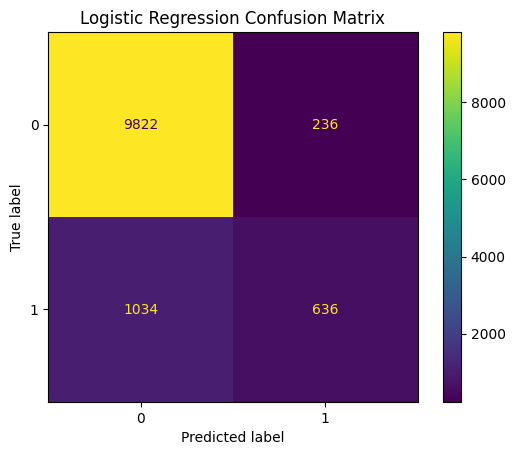

In [ ]:
#Plotting the confusion matrix to evaluate how well LR predicted the unseen test application statuses.

#Importing confusion_matrix and ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#Calculating the confusion matrix for LR test predictions
cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)

#Displaying the confusion matrix as a labelled plot
disp = ConfusionMatrixDisplay(cm, display_labels=logreg.classes_)
disp.plot()
disp.ax_.set_title("Logistic Regression Confusion Matrix")

## Code Reuse Session 2 - Prompt 18

In [ ]:
#Producing the full classification report [precision, recall, f1, accuracy] for LR on the test subset
#Importing classification_report and printing the full report
from sklearn.metrics import classification_report
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     10058
           1       0.73      0.38      0.50      1670

    accuracy                           0.89     11728
   macro avg       0.82      0.68      0.72     11728
weighted avg       0.88      0.89      0.88     11728



## Code Reuse Session 2 - Prompt 19

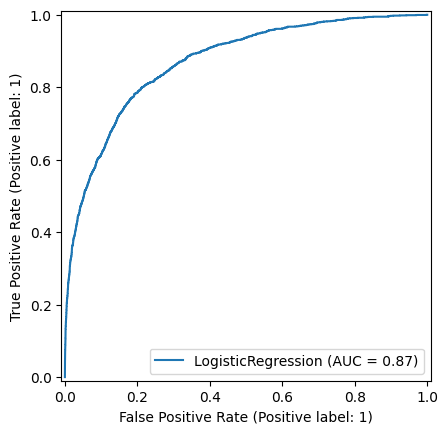

In [ ]:
#Displaying the AUC-ROC curve to assess LR's ability to distinguish between approved and rejected classes
#importing RocCurveDisplay and plot the AUC-ROC curve for LR on the test subset
from sklearn.metrics import RocCurveDisplay
logreg_roc = RocCurveDisplay.from_estimator(logreg, X_test, y_test)



---
# **MODEL 2 : K-NEAREST NEIGHBOURS (KNN)**


---





## Code Reuse Session 2 - Prompt 20

In [ ]:
#Importing KNeighborsClassifier from the sklearn module
from sklearn.neighbors import KNeighborsClassifier

## Code Reuse Session 2 - Prompt 21

In [ ]:
#Instantiate the KNN algorithm with n_neighbors=5 as the initial K value
knn = KNeighborsClassifier(n_neighbors=5)


## Code Reuse Session 2 - Prompt 22

In [ ]:
#Building the KNN model using the training data subset
knn.fit(X_train, y_train)

KNeighborsClassifier()

## Code Reuse Session 2 - Prompt 23

In [ ]:
#Applying the KNN model to predict loan approval statuses on the isolated unseen test subset
y_pred_knn = knn.predict(X_test)

#Predicting on training subset to check for overfitting
y_pred_train_knn = knn.predict(X_train)

## Code Reuse Session 2 - Prompt 15

In [ ]:
#Calculating KNN training accuracy to assess how well the model learned
accuracy_train_knn = accuracy_score(y_train, y_pred_train_knn)
print('KNN Training Accuracy: ', accuracy_train_knn)

KNN Training Accuracy:  0.937434716804161


## Code Reuse Session 2 - Prompt 16

In [ ]:
#Calculating and display KNN test accuracy score on unseen data
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print('KNN Test Accuracy: ', accuracy_knn)

KNN Test Accuracy:  0.9146487039563438


## Code Reuse Session 2 - Prompt 17

Text(0.5, 1.0, 'KNN Confusion Matrix')

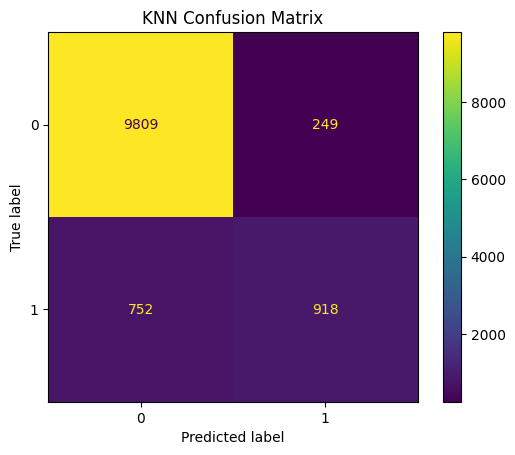

In [ ]:
#Calculating and display the confusion matrix for KNN on the test subset
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
disp_knn = ConfusionMatrixDisplay(cm_knn, display_labels=knn.classes_)
disp_knn.plot()
disp_knn.ax_.set_title("KNN Confusion Matrix")

## Code Reuse Session 2 - Prompt 18

In [ ]:
#Printing the full classification report for KNN on the test subset
print("KNN Classification Report")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10058
           1       0.79      0.55      0.65      1670

    accuracy                           0.91     11728
   macro avg       0.86      0.76      0.80     11728
weighted avg       0.91      0.91      0.91     11728



## Code Reuse Session 2 - Prompt 19

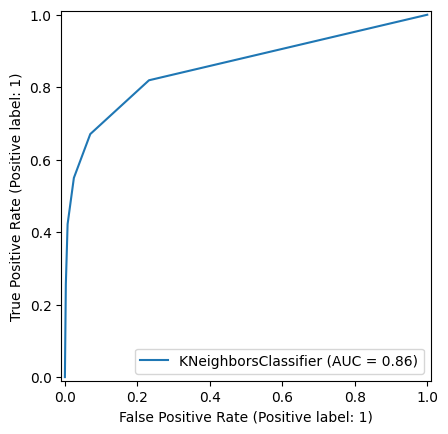

In [ ]:
#plotting the AUC-ROC curve for the KNN model on the test subset
knn_roc = RocCurveDisplay.from_estimator(knn, X_test, y_test)



---

# **MODEL 3 :  NAIVE BAYES (NB)**
---



## Code Reuse Session 2 - Prompt 27

In [ ]:
#Importing GaussianNB from the sklearn module
from sklearn.naive_bayes import GaussianNB

#Instantiate the Naive Bayes algorithm
nb = GaussianNB()

#Fit the Naive Bayes model on the training subset
nb.fit(X_train, y_train)

GaussianNB()

## Code Reuse Session 2 - Prompt 13

In [ ]:
#Using the trained NB model to predict loan approval status on the unseen test subset
y_pred_nb = nb.predict(X_test)

#Predicting on training subset to check for overfitting
y_pred_train_nb = nb.predict(X_train)

## Code Reuse Session 2 - Prompt 15

In [ ]:
#Calculating NB training accuracy to assess how well the model learned
accuracy_train_nb = accuracy_score(y_train, y_pred_train_nb)
print('NB Training Accuracy: ', accuracy_train_nb)

NB Training Accuracy:  0.8519110656349257


## Code Reuse Session 2 - Prompt 16

In [ ]:
#Calculating and displaying NB test accuracy score on unseen data
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print('NB Test Accuracy: ', accuracy_nb)

NB Test Accuracy:  0.8501023192360164


## Code Reuse Session 2 - Prompt 17

Text(0.5, 1.0, 'Naïve Bayes Confusion Matrix')

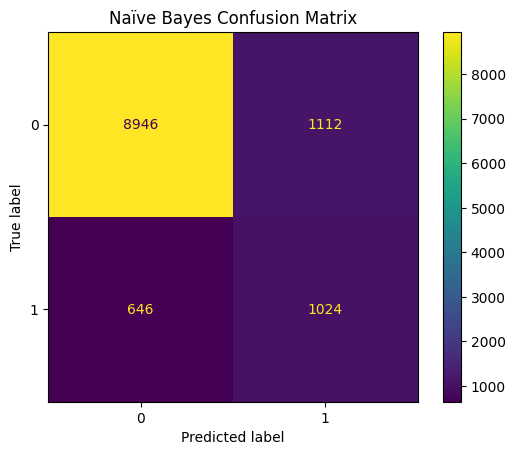

In [ ]:
#Calculating and displaying the confusion matrix for NB on the test subset
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb.classes_)
disp_nb = ConfusionMatrixDisplay(cm_nb, display_labels=nb.classes_)
disp_nb.plot()
disp_nb.ax_.set_title("Naïve Bayes Confusion Matrix")

## Code Reuse Session 2 - Prompt 18

In [ ]:
#Printing the full classification report for NB on the test subset
print("NB Classification Report")
print(classification_report(y_test, y_pred_nb))

NB Classification Report
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     10058
           1       0.48      0.61      0.54      1670

    accuracy                           0.85     11728
   macro avg       0.71      0.75      0.72     11728
weighted avg       0.87      0.85      0.86     11728



## Code Reuse Session 2 - Prompt 19

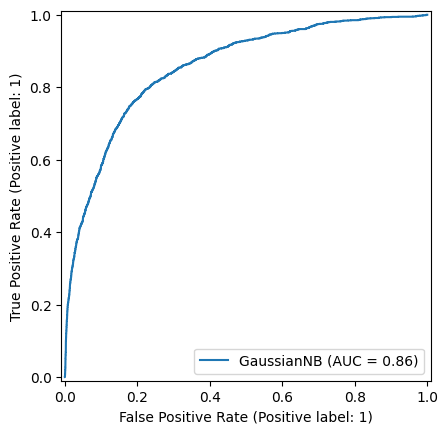

In [ ]:
#Plotting the AUC-ROC curve for the NB model on the test subset
nb_roc = RocCurveDisplay.from_estimator(nb, X_test, y_test)



---
# **HYPERPARAMETETR TUNING - GridSearchCV on KNN**

---



## Code Reuse Session 2 - Prompt 24

In [ ]:
#Importing GridSearchCV from sklearn to perform exhaustive hyperparameter search with cross-validation
from sklearn.model_selection import GridSearchCV

## Code Reuse Session 2 - Prompt 25

In [ ]:
#Defining the hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

#Instantiate GridSearchCV with KNN algorithm, parameter grid and 5-fold cross-validation
knn_gscv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

#Fitting GridSearchCV on the training data to find the best hyperparameter combination
knn_gscv.fit(X_train, y_train)

#Displaying the best hyperparameter configurations found
knn_gscv.best_params_

{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

## Code Reuse Session 2 - Prompt 26

In [ ]:
#Using the tuned GridSearchCV KNN model to predict loan approval statuses on the test subset
y_pred = knn_gscv.predict(X_test)

## Code Reuse Session 2 - Prompt 16

In [ ]:
#Calculate and displaying the test accuracy for the tuned KNN model
accuracy_tuned = accuracy_score(y_test, y_pred)
print('Tuned KNN Test Accuracy: ', accuracy_tuned)

Tuned KNN Test Accuracy:  0.9202762619372442


## Code Reuse Session 2 - Prompt 17

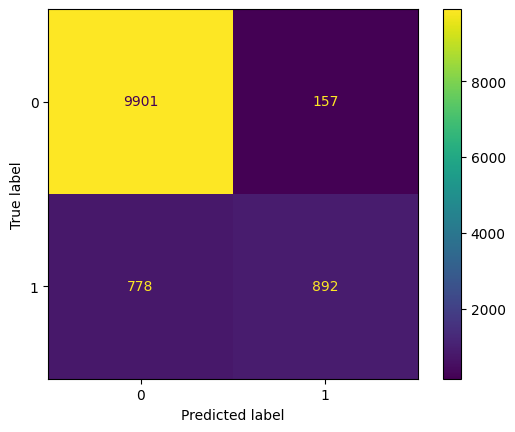

In [ ]:
#Calculate and displaying the confusion matrix for the tuned KNN model on the test subset
cm_tuned = confusion_matrix(y_test, y_pred, labels=knn_gscv.classes_)
disp_tuned = ConfusionMatrixDisplay(cm_tuned, display_labels=knn_gscv.classes_)
disp_tuned.plot()

## Code Reuse Session 2 - Prompt 18

In [ ]:
#Printing the full classification report for the tuned KNN model on the test subset
print('Tuned KNN Classification Report:')
print(classification_report(y_test, y_pred))

Tuned KNN Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     10058
           1       0.85      0.53      0.66      1670

    accuracy                           0.92     11728
   macro avg       0.89      0.76      0.81     11728
weighted avg       0.92      0.92      0.91     11728



## Code Reuse Session 2 - Prompt 19

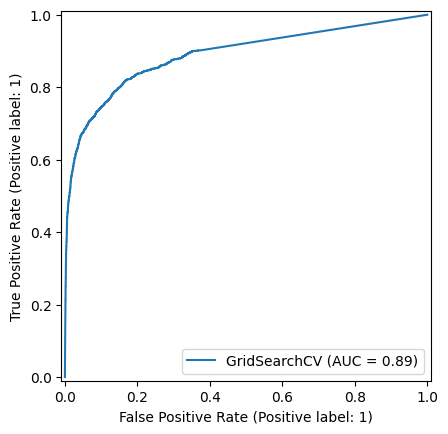

In [ ]:
#Plotting the AUC-ROC curve for the tuned KNN model on the test subset
tuned_roc = RocCurveDisplay.from_estimator(knn_gscv, X_test, y_test)